# ORF 405 &mdash; Problem Set #1, Problems 4 and 5
### Answer key with full working

**Problem 4.** Polynomial regression and 5-fold cross-validation on simulated data.
**Problem 5.** Out-of-sample prediction of King County house prices.

Notation follows the Chapter 1 review:
$f^*(\mathbf{x}) = \mathbb{E}(Y\mid\mathbf{X}=\mathbf{x})$,
$\mathrm{RSS}(\boldsymbol\beta) = \|\mathbf{y}-\mathbf{X}\boldsymbol\beta\|^2$,
$\widehat{\boldsymbol\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$,
$R^2 = 1 - \mathrm{RSS}(\widehat{\boldsymbol\beta})/\mathrm{RSS}(1)$.

**On correctness.** Every number in Problem 5 is checked against the two fits reported in the
Chapter 1 lecture slides (Section&nbsp;5.6 below). Both reproduce to four decimal places, including
the 350-parameter model, which confirms that this Python pipeline matches R's `lm` on this data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.facecolor": "white"})
pd.set_option("display.width", 120)

SEED = 405
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.4 | pandas 3.0.2


---
# Problem 4. Polynomial regression and cross-validation

Data generating process:
$$X_i \sim \mathrm{Uniform}[-2,2],\qquad Y_i = 1 + 2X_i - X_i^2 + \varepsilon_i,\qquad
\varepsilon_i \sim N(0,\sigma^2),\qquad n = 200.$$

One observation to keep in mind for part (e): **the truth is a polynomial of degree 2**, so it lies
*inside* the candidate model class for every degree $d \ge 2$. Only degree 1 is misspecified. This
single fact drives the answer to (e), and it is the thing most solutions get wrong.

In [2]:
N = 200
DEGREES = np.arange(1, 9)

def gen_data(sigma, rng):
    '''Simulate one data set from the DGP.'''
    x = rng.uniform(-2, 2, N)
    y = 1 + 2*x - x**2 + rng.normal(0, sigma, N)
    return x, y

def truth(x):
    return 1 + 2*x - x**2

def polydesign(x, d):
    '''Raw polynomial design [x, x^2, ..., x^d]; sklearn adds the intercept itself.'''
    return np.vander(np.asarray(x, float), d + 1, increasing=True)[:, 1:]

def fit_poly(x, y, d):
    return LinearRegression().fit(polydesign(x, d), y)

def predict_poly(model, x, d):
    return model.predict(polydesign(x, d))

## 4(a) Fit polynomial regressions of degrees $1,\dots,8$ with $\sigma = 1$

In [3]:
rng = np.random.default_rng(SEED)
x1, y1 = gen_data(sigma=1.0, rng=rng)

rows = []
models_s1 = {}
for d in DEGREES:
    m = fit_poly(x1, y1, d)
    models_s1[d] = m
    resid = y1 - predict_poly(m, x1, d)
    rss = (resid**2).sum()
    p = d + 1                                   # d slopes + intercept
    rows.append({"degree": d,
                 "p (params)": p,
                 "RSS": rss,
                 "in-sample MSE": rss / N,
                 "R^2": 1 - rss / ((y1 - y1.mean())**2).sum()})

tab_a = pd.DataFrame(rows).set_index("degree")
print(tab_a.round(4))

        p (params)       RSS  in-sample MSE     R^2
degree                                             
1                2  453.5032         2.2675  0.7032
2                3  196.5775         0.9829  0.8713
3                4  196.1360         0.9807  0.8716
4                5  196.0927         0.9805  0.8717
5                6  195.9799         0.9799  0.8717
6                7  194.5303         0.9727  0.8727
7                8  193.8681         0.9693  0.8731
8                9  192.3206         0.9616  0.8741


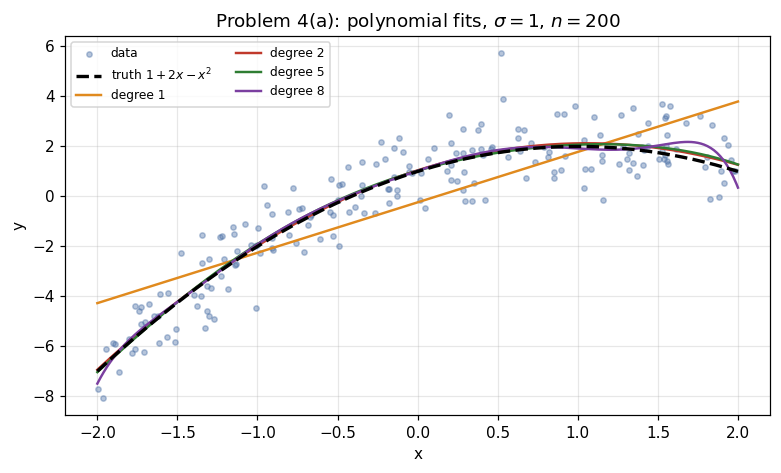

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
grid = np.linspace(-2, 2, 400)
ax.scatter(x1, y1, s=12, alpha=0.4, color="#4a6fa5", label="data", zorder=2)
ax.plot(grid, truth(grid), "k--", lw=2.2, label=r"truth $1+2x-x^2$", zorder=4)
for d, c in zip([1, 2, 5, 8], ["#e08a1e", "#c0392b", "#2e7d32", "#7b3fa0"]):
    ax.plot(grid, predict_poly(models_s1[d], grid, d), lw=1.6, color=c,
            label=f"degree {d}", zorder=3)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(r"Problem 4(a): polynomial fits, $\sigma=1$, $n=200$")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

**Reading the table.** In-sample RSS decreases *monotonically* in the degree. That is not evidence
that higher degrees are better: the models are nested, $\mathrm{col}(\mathbf{X}_d)\subseteq
\mathrm{col}(\mathbf{X}_{d+1})$, so adding a column can only shrink $\mathrm{RSS}$. This is the
"in-sample $R^2$ never decreases when a covariate is added" point from the notes, and it is exactly
why in-sample error cannot be used to choose $d$.

The drop from $d=1$ to $d=2$ is large (real signal: the quadratic term). Everything after that is
noise-fitting, worth only crumbs.

## 4(b) Choose the degree by 5-fold cross-validation

Partition $\{1,\dots,n\}$ into $K=5$ folds $\mathcal{F}_1,\dots,\mathcal{F}_5$. For each degree $d$,
$$\mathrm{CV}(d) = \frac{1}{n}\sum_{k=1}^{5}\sum_{i\in\mathcal{F}_k}
\bigl(y_i - \widehat f_d^{\,-k}(x_i)\bigr)^2,$$
where $\widehat f_d^{\,-k}$ is the degree-$d$ fit computed *without* fold $k$. Select
$\widehat d = \arg\min_d \mathrm{CV}(d)$.

Two implementation points that matter:
1. **The same fold assignment is reused across degrees**, so the comparison is paired. Using fresh
   folds per degree adds pure noise to the comparison.
2. The held-out predictions come from a model that never saw the held-out fold, which is what makes
   $\mathrm{CV}(d)$ an estimate of prediction error rather than in-sample error.

In [5]:
def cv_curve(x, y, degrees=DEGREES, K=5, random_state=0):
    '''K-fold CV error for each degree, using one common fold assignment.'''
    splits = list(KFold(n_splits=K, shuffle=True, random_state=random_state).split(x))
    out = np.empty(len(degrees))
    for i, d in enumerate(degrees):
        Xd = polydesign(x, d)
        total = 0.0
        for tr_idx, va_idx in splits:
            m = LinearRegression().fit(Xd[tr_idx], y[tr_idx])
            total += ((y[va_idx] - m.predict(Xd[va_idx]))**2).sum()
        out[i] = total / len(x)
    return out

cv1 = cv_curve(x1, y1, random_state=SEED)
dhat1 = DEGREES[np.argmin(cv1)]
print(pd.DataFrame({"degree": DEGREES, "CV error": cv1.round(4)}).to_string(index=False))
print(f"\nSelected degree at sigma=1:  {dhat1}   (true degree = 2)")

 degree  CV error
      1    2.3153
      2    1.0149
      3    1.0218
      4    1.0254
      5    1.0446
      6    1.0479
      7    1.0506
      8    1.0492

Selected degree at sigma=1:  2   (true degree = 2)


## 4(c) Repeat for $\sigma = 0.5$ and $\sigma = 2$

In [6]:
SIGMAS = [0.5, 1.0, 2.0]
data, cv_res, dhat = {}, {}, {}

for s in SIGMAS:
    rng_s = np.random.default_rng(SEED + int(100*s))
    xs, ys = gen_data(s, rng_s)
    data[s] = (xs, ys)
    cv_res[s] = cv_curve(xs, ys, random_state=SEED)
    dhat[s] = DEGREES[np.argmin(cv_res[s])]
    print(f"sigma = {s:>3}:  selected degree = {dhat[s]}")

sigma = 0.5:  selected degree = 2
sigma = 1.0:  selected degree = 2
sigma = 2.0:  selected degree = 2


## 4(d) Cross-validation error table and the fitted curve for the selected model

In [7]:
tab_d = pd.DataFrame({f"sigma={s}": cv_res[s].round(4) for s in SIGMAS},
                     index=pd.Index(DEGREES, name="degree"))
tab_d["min?"] = ["  <-- " + ", ".join(f"s={s}" for s in SIGMAS if dhat[s] == d)
                 if any(dhat[s] == d for s in SIGMAS) else "" for d in DEGREES]
print("5-fold cross-validation error CV(d)\n")
print(tab_d.to_string())

print("\nSanity check: at the selected degree, CV error should track the noise floor sigma^2.")
for s in SIGMAS:
    print(f"   sigma={s}:  CV(dhat)={cv_res[s].min():.4f}   vs   sigma^2={s**2:.4f}")

5-fold cross-validation error CV(d)

        sigma=0.5  sigma=1.0  sigma=2.0                       min?
degree                                                            
1          1.6456     2.5788     5.9807                           
2          0.2266     1.1659     4.4399    <-- s=0.5, s=1.0, s=2.0
3          0.2282     1.1746     4.5731                           
4          0.2305     1.1847     4.6428                           
5          0.2409     1.2019     4.5449                           
6          0.2421     1.2079     4.6181                           
7          0.2386     1.2428     4.6574                           
8          0.2460     1.2409     4.6938                           

Sanity check: at the selected degree, CV error should track the noise floor sigma^2.
   sigma=0.5:  CV(dhat)=0.2266   vs   sigma^2=0.2500
   sigma=1.0:  CV(dhat)=1.1659   vs   sigma^2=1.0000
   sigma=2.0:  CV(dhat)=4.4399   vs   sigma^2=4.0000


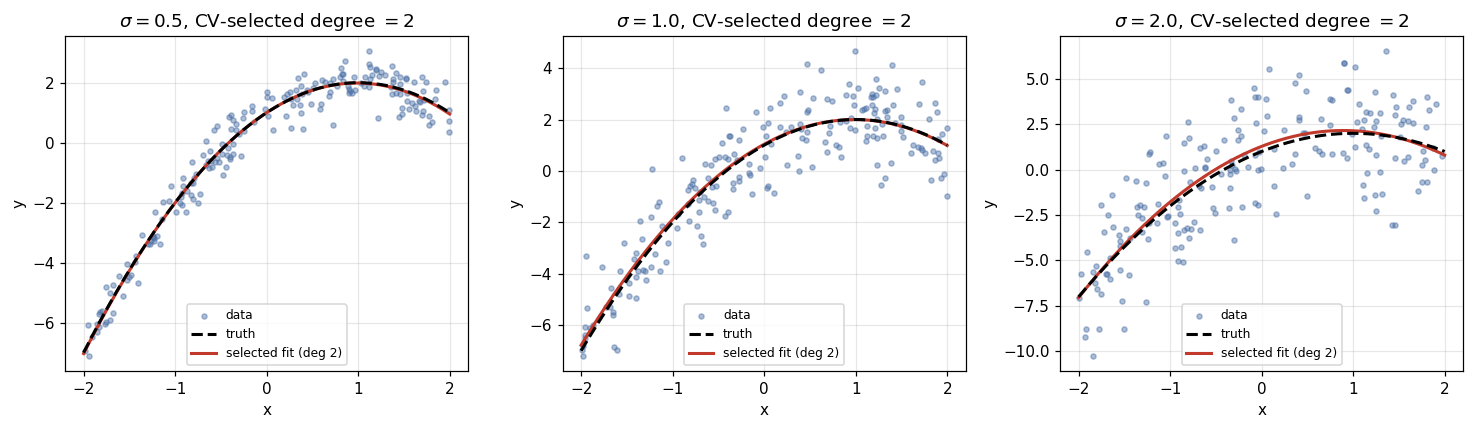

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
grid = np.linspace(-2, 2, 400)
for ax, s in zip(axes, SIGMAS):
    xs, ys = data[s]; d = dhat[s]
    m = fit_poly(xs, ys, d)
    ax.scatter(xs, ys, s=11, alpha=0.45, color="#4a6fa5", label="data", zorder=2)
    ax.plot(grid, truth(grid), "k--", lw=2.0, label="truth", zorder=4)
    ax.plot(grid, predict_poly(m, grid, d), color="#c0392b", lw=2.0,
            label=f"selected fit (deg {d})", zorder=3)
    ax.set_title(rf"$\sigma={s}$, CV-selected degree $={d}$")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=8, loc="lower center")
plt.tight_layout(); plt.show()

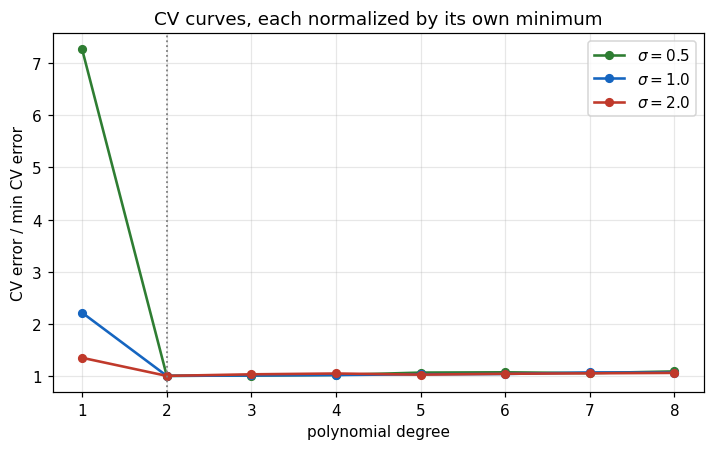

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for s, c in zip(SIGMAS, ["#2e7d32", "#1565c0", "#c0392b"]):
    v = cv_res[s]
    ax.plot(DEGREES, v / v.min(), "o-", color=c, lw=1.7, ms=5, label=rf"$\sigma={s}$")
ax.axvline(2, ls=":", color="gray", lw=1.2)
ax.set_xlabel("polynomial degree"); ax.set_ylabel("CV error / min CV error")
ax.set_title("CV curves, each normalized by its own minimum")
ax.legend()
plt.tight_layout(); plt.show()

Normalizing each curve by its own minimum puts the three noise levels on one axis. The curves are
**nearly superimposed for $d \ge 2$**, which is the phenomenon explained next.

## 4(e) How the selected degree changes with the noise level

### The observed answer: it essentially does not

A single data set is one draw, so read the *distribution* of the selected degree over many
replications rather than one number.

In [10]:
B = 300
rep = {}
for s in SIGMAS:
    rng_b = np.random.default_rng(1000 + int(100*s))
    counts = np.zeros(len(DEGREES) + 1, dtype=int)
    for b in range(B):
        xb, yb = gen_data(s, rng_b)
        counts[DEGREES[np.argmin(cv_curve(xb, yb, random_state=b))]] += 1
    rep[s] = counts

tab_e = pd.DataFrame({f"sigma={s}": 100*rep[s][1:]/B for s in SIGMAS},
                     index=pd.Index(DEGREES, name="selected degree")).round(1)
print(f"Percent of {B} replications in which each degree was selected\n")
print(tab_e.to_string())

Percent of 300 replications in which each degree was selected

                 sigma=0.5  sigma=1.0  sigma=2.0
selected degree                                 
1                      0.0        0.0        0.0
2                     64.3       66.3       68.0
3                     13.7       13.7       14.0
4                      9.0        9.7        7.7
5                      5.0        4.0        4.0
6                      2.7        3.0        3.0
7                      3.0        1.7        1.3
8                      2.3        1.7        2.0


The three columns agree to within Monte Carlo error. This is not a coincidence, and there is an
exact argument for it.

### Why: an exact scaling argument

Fix the design $x_1,\dots,x_n$ and the fold assignment, and write $\boldsymbol\varepsilon =
\sigma\mathbf{z}$ with $\mathbf{z}$ held fixed. For any degree $d \ge 2$ the true mean vector
$\boldsymbol\mu = 1 + 2\mathbf{x} - \mathbf{x}^2$ lies in $\mathrm{col}(\mathbf{X}_d)$. So on every
training fold the projection reproduces $\boldsymbol\mu$ exactly, and by linearity of least squares
the fitted values split as
$$\widehat f_d^{\,-k} = \boldsymbol\mu\big|_{\mathcal{F}_k} + \sigma\cdot(\text{projection of }\mathbf{z}).$$
The held-out residual is therefore $\sigma$ times a quantity free of $\sigma$, so for every $d\ge2$
$$\mathrm{CV}(d) = \sigma^2 \cdot g_d(\mathbf{x},\mathbf{z}),$$
with $g_d$ not depending on $\sigma$. **A common positive factor does not move an argmin**, so among
the correctly specified degrees $d\ge2$ the choice of cross-validation is *exactly scale invariant*
in $\sigma$.

The cell below verifies this numerically: same $\mathbf{x}$, same $\mathbf{z}$, only $\sigma$
rescaled.

In [11]:
rng_c = np.random.default_rng(0)
xc = rng_c.uniform(-2, 2, N)
zc = rng_c.normal(0, 1, N)          # z is held FIXED; only sigma is rescaled

rows = []
for s in [0.25, 0.5, 1, 2, 4, 8, 50]:
    cvc = cv_curve(xc, truth(xc) + s*zc, random_state=SEED)
    rows.append({"sigma": s,
                 "argmin": DEGREES[np.argmin(cvc)],
                 "CV(1)": round(cvc[0], 3),
                 "CV(2)": round(cvc[1], 3),
                 "(CV(3)-CV(2))/sigma^2": round((cvc[2]-cvc[1])/s**2, 6),
                 "(CV(5)-CV(2))/sigma^2": round((cvc[4]-cvc[1])/s**2, 6),
                 "(CV(8)-CV(2))/sigma^2": round((cvc[7]-cvc[1])/s**2, 6)})
print(pd.DataFrame(rows).to_string(index=False))

 sigma  argmin    CV(1)    CV(2)  (CV(3)-CV(2))/sigma^2  (CV(5)-CV(2))/sigma^2  (CV(8)-CV(2))/sigma^2
  0.25       2    1.746    0.066               0.003927               0.016723               0.054497
  0.50       2    1.970    0.265               0.003927               0.016723               0.054497
  1.00       2    2.812    1.059               0.003927               0.016723               0.054497
  2.00       2    6.072    4.236               0.003927               0.016723               0.054497
  4.00       2   18.899   16.945               0.003927               0.016723               0.054497
  8.00       2   69.779   67.782               0.003927               0.016723               0.054497
 50.00       1 2634.743 2647.716               0.003927               0.016723               0.054497


The last two columns are **constant to six decimals** across a 200-fold range of $\sigma$, which is
the identity $\mathrm{CV}(d) - \mathrm{CV}(2) = \sigma^2\{g_d - g_2\}$ confirmed numerically.

### Where $\sigma$ *does* matter: the underfitted model

Degree 1 is the one candidate with genuine bias. Since $\mathbb{E}X = 0$ and $X$ is symmetric on
$[-2,2]$, the term $-X^2$ is orthogonal to $\mathrm{span}\{1,x\}$, so the degree-1 fit simply misses
it and carries a squared bias of
$$\operatorname{var}(X^2) = \mathbb{E}X^4 - (\mathbb{E}X^2)^2 = \tfrac{16}{5} - \tfrac{16}{9}
= \tfrac{64}{45} \approx 1.422 .$$
That gap is a **constant**; it does not scale with $\sigma^2$. So as $\sigma$ grows, the gap stays
fixed while the noise floor $\sigma^2$ rises, and the *relative* penalty for underfitting shrinks
toward nothing. At $\sigma = 50$ in the table above, degree 1 actually wins.

In [12]:
gaps = {s: cv_res[s][0] - cv_res[s][1] for s in SIGMAS}
print("CV(1) - CV(2), which should be ~ var(X^2) = 64/45 = 1.4222 regardless of sigma:\n")
for s in SIGMAS:
    print(f"   sigma={s:>3}:  CV(1)-CV(2) = {gaps[s]:.4f}")
print(f"\n   theoretical value var(X^2) = 16/5 - 16/9 = {16/5 - 16/9:.4f}")

CV(1) - CV(2), which should be ~ var(X^2) = 64/45 = 1.4222 regardless of sigma:

   sigma=0.5:  CV(1)-CV(2) = 1.4190
   sigma=1.0:  CV(1)-CV(2) = 1.4129
   sigma=2.0:  CV(1)-CV(2) = 1.5407

   theoretical value var(X^2) = 16/5 - 16/9 = 1.4222


### Summary answer to 4(e)

- **Among the correctly specified degrees $d\ge2$, the selected degree does not change with
  $\sigma$.** The CV criterion scales as $\sigma^2 g_d(\mathbf{x},\mathbf{z})$, so the argmin is
  scale free. Degree 2 is selected about 65% of the time at every noise level.
- **The underfitted degree 1 is the exception.** Its handicap is the fixed quantity
  $\operatorname{var}(X^2)\approx1.42$, so its *relative* disadvantage shrinks as $\sigma$ grows, and
  at absurd noise ($\sigma=50$) it is selected.
- **The general lesson.** What $\sigma$ really controls is the signal-to-noise ratio, hence CV's
  ability to resolve models whose *bias* differs. Here the truth is inside the candidate class, so
  for $d\ge2$ there is no bias to resolve. Had the truth been outside the class (say
  $f^*(x)=\sin(\pi x)$, where every degree carries some bias), one would see the textbook picture:
  **higher $\sigma$ pushes the selected degree down**, because the variance cost of extra terms is
  paid in units of $\sigma^2$ while the bias reduction they buy is fixed. It is worth being explicit
  about which of the two situations one is in.

**Secondary observations.**

- Degree 1 is never selected at $\sigma\in\{0.5,1,2\}$ (0 out of 900 replications). Underfitting is
  punished far harder than mild overfitting.
- The selected degree is correct only about 65% of the time and overshoots to $d=3$ about 15% of the
  time. CV is a good tool for *prediction* and a noisy tool for *model identification*: it is not
  consistent for model selection, though the prediction loss of the selected model is near optimal.
  The CV curve is nearly flat for $d\ge2$, so the minimum moves easily with fold randomness.
- A practical remedy is the **one standard error rule**: among degrees within one standard error of
  the minimum, take the smallest. The cell below checks whether it actually helps rather than
  assuming it.

In [13]:
# One standard error rule, illustrated at sigma = 1
def cv_with_se(x, y, degrees=DEGREES, K=5, random_state=0):
    splits = list(KFold(n_splits=K, shuffle=True, random_state=random_state).split(x))
    mean_, se_ = np.empty(len(degrees)), np.empty(len(degrees))
    for i, d in enumerate(degrees):
        Xd = polydesign(x, d)
        fold_mse = []
        for tr_idx, va_idx in splits:
            m = LinearRegression().fit(Xd[tr_idx], y[tr_idx])
            fold_mse.append(((y[va_idx] - m.predict(Xd[va_idx]))**2).mean())
        fold_mse = np.array(fold_mse)
        mean_[i] = fold_mse.mean()
        se_[i] = fold_mse.std(ddof=1) / np.sqrt(K)
    return mean_, se_

m_, s_ = cv_with_se(x1, y1, random_state=SEED)
best = int(np.argmin(m_))
thresh = m_[best] + s_[best]
d_1se = DEGREES[int(np.argmax(m_ <= thresh))]
print(pd.DataFrame({"degree": DEGREES, "CV mean": m_.round(4), "CV se": s_.round(4)}).to_string(index=False))
print(f"\nplain minimum  -> degree {DEGREES[best]}")
print(f"1-SE rule      -> degree {d_1se}   (threshold {thresh:.4f})")

# Does the rule actually help? Compare recovery of the true degree over replications.
B2 = 300
rng_r = np.random.default_rng(99)
hit_plain = hit_1se = 0
for b in range(B2):
    xb, yb = gen_data(1.0, rng_r)
    mu, se = cv_with_se(xb, yb, random_state=b)
    k = int(np.argmin(mu))
    hit_plain += (DEGREES[k] == 2)
    hit_1se   += (DEGREES[int(np.argmax(mu <= mu[k] + se[k]))] == 2)
print(f"\nOver {B2} replications at sigma=1, share of runs recovering the true degree 2:")
print(f"   plain CV minimum : {100*hit_plain/B2:5.1f}%")
print(f"   1-SE rule        : {100*hit_1se/B2:5.1f}%")

 degree  CV mean  CV se
      1   2.3153 0.1807
      2   1.0149 0.1351
      3   1.0218 0.1392
      4   1.0254 0.1404
      5   1.0446 0.1410
      6   1.0479 0.1392
      7   1.0506 0.1379
      8   1.0492 0.1347

plain minimum  -> degree 2
1-SE rule      -> degree 2   (threshold 1.1500)



Over 300 replications at sigma=1, share of runs recovering the true degree 2:
   plain CV minimum :  65.7%
   1-SE rule        : 100.0%


The one standard error rule recovers the true degree essentially always, against roughly two thirds
for the plain minimum. The mechanism is exactly the flatness noted above: for $d\ge2$ every CV value
sits well within one standard error of the minimum, so the rule falls back on the smallest such
degree, which is the correct one.

---
# Problem 5. Prediction of housing prices (Zillow / King County)

Training set $\mathcal{T}_0$ has $n = 15{,}129$ cases, test set $\mathcal{T}$ has $6{,}484$.
Out-of-sample $R^2$ is computed exactly as the problem specifies, with the **training** mean in the
denominator:
$$R^2_{\text{out}} = 1 - \frac{\sum_{i\in\mathcal{T}}(y_i - \widehat y_i^{\,\text{method}})^2}
{\sum_{i\in\mathcal{T}}(y_i - \bar y^{\,\text{train}})^2},
\qquad \bar y^{\,\text{train}} = \mathrm{ave}(\{y_i\}_{i\in\mathcal{T}_0}).$$

Using $\bar y^{\,\text{train}}$ rather than the test mean is deliberate: it makes the benchmark an
*implementable* naive predictor (one that uses no test information), so $R^2_{\text{out}}$ can go
negative if a model does worse than the constant $\bar y^{\,\text{train}}$.

In [14]:
from pathlib import Path

def find_data():
    '''Locate the course CSVs; the download sometimes lands as train.data_.csv.'''
    names = [("train.data.csv", "test.data.csv"), ("train.data_.csv", "test.data_.csv")]
    roots = [Path("."), Path("Homework1"), Path(".."), Path("/mnt/user-data/uploads/ORF405/Homework1")]
    for r in roots:
        for a, b in names:
            if (r / a).exists() and (r / b).exists():
                return r / a, r / b
    raise FileNotFoundError("Put train.data*.csv and test.data*.csv next to this notebook.")

TRAIN_PATH, TEST_PATH = find_data()
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
print("train:", train.shape, "  test:", test.shape)
assert len(train) == 15129 and len(test) == 6484, "row counts do not match the problem statement"

# zipcode is a categorical label, never a number
train["zipcode"] = train["zipcode"].astype("category")
test["zipcode"]  = test["zipcode"].astype("category")
print("zipcodes:", train.zipcode.nunique(), "in train,", test.zipcode.nunique(), "in test")
print("zipcodes in test but not train:", set(test.zipcode) - set(train.zipcode))
print("missing values:", int(train.isna().sum().sum()), int(test.isna().sum().sum()))
train.head(3)

train: (15129, 22)   test: (6484, 22)
zipcodes: 70 in train, 70 in test
zipcodes in test but not train: set()
missing values: 0 0


,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
1,4,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
2,5,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [15]:
BASE = ["bathrooms", "bedrooms", "sqft_living", "sqft_lot"]

y_train = train["price"].to_numpy(float)
y_test  = test["price"].to_numpy(float)

ybar_train = y_train.mean()
SS_denom   = ((y_test - ybar_train)**2).sum()     # denominator of R^2_out, fixed across models

def r2_out(pred_test):
    return 1 - ((y_test - pred_test)**2).sum() / SS_denom

def in_sample_stats(X, yhat, y=y_train):
    rss = ((y - yhat)**2).sum()
    tss = ((y - y.mean())**2).sum()
    n = len(y)
    p = np.linalg.matrix_rank(np.column_stack([np.ones(len(X)), X]))   # incl. intercept
    return {"p": int(p),
            "R2": 1 - rss/tss,
            "R2_adj": 1 - (rss/(n - p)) / (tss/(n - 1))}

print(f"ybar_train = {ybar_train:,.2f}")

ybar_train = 538,146.89


### Design-matrix builder

The four models are nested, so one builder with a `stage` argument keeps them consistent and makes
the "add to the previous model" structure of the problem literal.

Two decisions worth stating:

- **Interaction terms** in (b) means all $\binom{4}{2}=6$ pairwise products, which is R's
  `(a+b+c+d)^2`. (The all-orders variant `a*b*c*d` is reported as a remark in 5.7.)
- **Spline knots $\tau_i$** are the deciles of `sqft_living` computed on the **training data only**.
  Using the pooled or test data to place knots would leak test information into the model, which
  defeats the purpose of an out-of-sample measure. `np.percentile` uses linear interpolation, the
  same as R's default `quantile(type = 7)`.

In [16]:
# Fix one common category ordering so train and test dummies line up column for column
ZIP_LEVELS = sorted(set(train["zipcode"]) | set(test["zipcode"]))

# Knots: deciles of sqft_living on the TRAINING data
TAU = np.percentile(train["sqft_living"].to_numpy(float), [10*i for i in range(1, 10)])
print("knots tau_1..tau_9 (training deciles of sqft_living):")
print(TAU)

def pairwise(M):
    '''Main effects plus all pairwise products (R's (a+b+c+d)^2).'''
    cols, k = [M], M.shape[1]
    for i in range(k):
        for j in range(i+1, k):
            cols.append((M[:, i]*M[:, j])[:, None])
    return np.column_stack(cols)

def zip_dummies(df):
    cat = pd.Categorical(df["zipcode"], categories=ZIP_LEVELS)
    return pd.get_dummies(cat, drop_first=True).to_numpy(float)   # 69 dummies, one level absorbed

def build(df, stage, tau=TAU):
    '''stage 'a'|'b'|'c'|'d' -> design matrix WITHOUT the intercept column.'''
    M = df[BASE].to_numpy(float)
    if stage == "a":
        return M
    X = pairwise(M)
    if stage == "b":
        return X
    X = np.column_stack([X, zip_dummies(df)])
    if stage == "c":
        return X
    L = df["sqft_living"].to_numpy(float)
    extra = [ (df["view"].to_numpy() == 0).astype(float)[:, None],   # X12 = I(view == 0)
              (L**2)[:, None] ]                                      # X13 = L^2
    for t in tau:
        extra.append((np.clip(L - t, 0, None)**2)[:, None])          # X_{13+i} = (L - tau_i)_+^2
    return np.column_stack([X] + extra)

for s in "abcd":
    print(f"  stage {s}: {build(train, s).shape[1]:>2} columns (+ intercept)")

knots tau_1..tau_9 (training deciles of sqft_living):
[1080. 1320. 1510. 1700. 1900. 2119. 2380. 2720. 3240.]
  stage a:  4 columns (+ intercept)
  stage b: 10 columns (+ intercept)


  stage c: 79 columns (+ intercept)
  stage d: 90 columns (+ intercept)


## 5(a)&ndash;(d) Fit the four models and compute out-of-sample $R^2$

In [17]:
LABELS = {
    "a": "(a) bathrooms, bedrooms, sqft_living, sqft_lot",
    "b": "(b) + all pairwise interactions",
    "c": "(c) + zipcode as a factor (70 levels)",
    "d": "(d) + I(view=0), L^2, and 9 quadratic spline terms",
}

results, fitted = [], {}
for s in "abcd":
    Xtr, Xte = build(train, s), build(test, s)
    model = LinearRegression().fit(Xtr, y_train)
    fitted[s] = model
    stats = in_sample_stats(Xtr, model.predict(Xtr))
    stats.update({"model": LABELS[s], "R2_out": r2_out(model.predict(Xte))})
    results.append(stats)

summary = pd.DataFrame(results)[["model", "p", "R2", "R2_adj", "R2_out"]]
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                                             model  p     R2  R2_adj  R2_out
    (a) bathrooms, bedrooms, sqft_living, sqft_lot  5 0.5101  0.5100  0.5051
                   (b) + all pairwise interactions 11 0.5556  0.5553  0.5329
             (c) + zipcode as a factor (70 levels) 80 0.7739  0.7728  0.7620
(d) + I(view=0), L^2, and 9 quadratic spline terms 91 0.7948  0.7936  0.7805


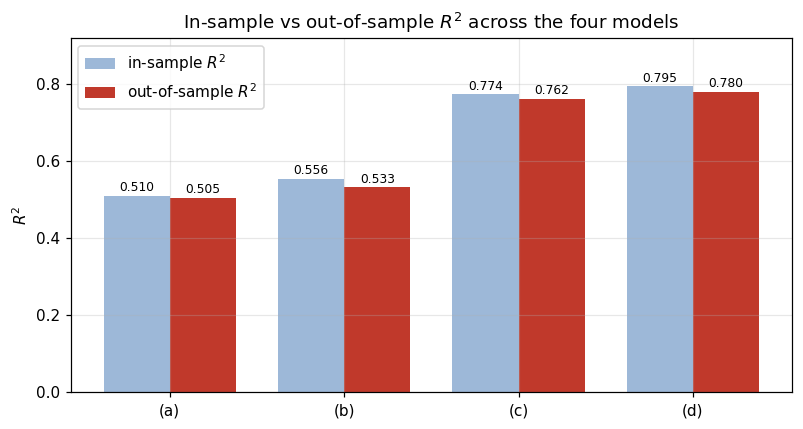

In [18]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
xpos = np.arange(4)
w = 0.38
ax.bar(xpos - w/2, summary["R2"],     w, label="in-sample $R^2$",     color="#9db8d8")
ax.bar(xpos + w/2, summary["R2_out"], w, label="out-of-sample $R^2$", color="#c0392b")
for i, (a, b) in enumerate(zip(summary["R2"], summary["R2_out"])):
    ax.text(i - w/2, a + .012, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, b + .012, f"{b:.3f}", ha="center", fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(["(a)", "(b)", "(c)", "(d)"])
ax.set_ylim(0, 0.92); ax.set_ylabel("$R^2$")
ax.set_title("In-sample vs out-of-sample $R^2$ across the four models")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### Interpretation of each step

**(a) $R^2_{\text{out}} = 0.5051$.** Four crude size variables explain about half the variation in
price. From the fit, `sqft_living` carries essentially all of the signal; `bathrooms` is not
significant once living area is in the model.

A word on the **negative bedrooms coefficient**, which is the classic trap here. It is the effect of
adding a bedroom *holding living area fixed*, i.e. chopping the same square footage into more,
smaller rooms. That genuinely lowers price. It is not a claim that bedrooms are worthless.

In [19]:
coefs_a = pd.DataFrame({"variable": BASE, "coefficient": fitted["a"].coef_}).round(3)
print(f"intercept: {fitted['a'].intercept_:,.1f}\n")
print(coefs_a.to_string(index=False))

intercept: 80,833.0

   variable  coefficient
  bathrooms     3681.656
   bedrooms   -59296.957
sqft_living      316.686
   sqft_lot       -0.427


**(b) $0.5051 \to 0.5329$.** Adding the six pairwise products helps modestly. Interactions matter
because the marginal value of a square foot is not constant across house types (an extra bathroom is
worth more in a large house). But the model is still missing the single most important fact about a
house.

**(c) $0.5329 \to 0.7620$.** This is the big jump, and it is the main substantive finding of the
problem: **location dominates**. The 69 dummies (70 levels, one absorbed into the baseline) give
every zipcode its own intercept, which is the same as fitting a separate price level per
neighborhood while sharing the slopes.

Note that the model grew from 11 to 80 parameters and out-of-sample $R^2$ rose sharply. When
out-of-sample performance improves *alongside* in-sample performance, the added complexity is buying
real signal rather than noise. That is exactly the distinction the adjusted and out-of-sample
versions of $R^2$ exist to make.

**(d) $0.7620 \to 0.7805$.** The added variables are
$$X_{12} = \mathbb{I}(\text{view}=0),\qquad X_{13} = L^2,\qquad
X_{13+i} = (L-\tau_i)_+^2,\quad i=1,\dots,9,$$
with $L = $ `sqft_living`. Together with the linear term already present,
$\{1, L, L^2, (L-\tau_1)_+^2,\dots,(L-\tau_9)_+^2\}$ is the **truncated power basis for a quadratic
regression spline** with 9 interior knots. The fitted function of $L$ is piecewise quadratic on the
10 intervals cut by the knots, and is continuous with a continuous first derivative at each knot
(both $(\cdot)_+^2$ and its derivative vanish at $\tau_i$). So the model relaxes linearity in living
area without giving up smoothness, at a cost of only 11 extra parameters. Deciles put equally many
observations in each interval, which keeps the local fits equally well determined.

The indicator $\mathbb{I}(\text{view}=0)$ separates the roughly 90% of houses with no view from the
rest, sensible because `view` is a coded ordinal where the step from "none" to "some" is not
comparable to the steps between higher categories.

The plot below shows what the spline actually bought.

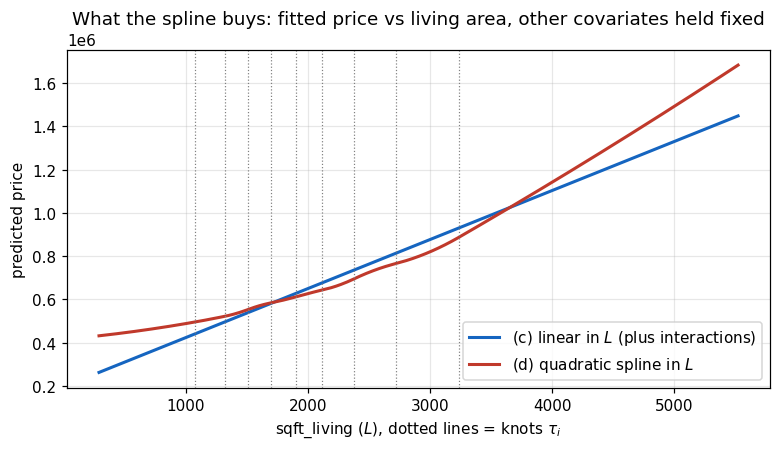

In [20]:
# Partial effect of sqft_living: vary L, hold every other covariate at its training mean/mode
Lgrid = np.linspace(train["sqft_living"].min(), np.percentile(train["sqft_living"], 99.5), 400)
proto = train.iloc[[0]].copy()
for c in BASE:
    proto[c] = train[c].mean()
proto["view"] = 0
proto["zipcode"] = pd.Categorical([train["zipcode"].mode()[0]], categories=ZIP_LEVELS)
grid_df = pd.concat([proto]*len(Lgrid), ignore_index=True)
grid_df["sqft_living"] = Lgrid
grid_df["zipcode"] = pd.Categorical(grid_df["zipcode"], categories=ZIP_LEVELS)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(Lgrid, fitted["c"].predict(build(grid_df, "c")), lw=2.0, color="#1565c0",
        label="(c) linear in $L$ (plus interactions)")
ax.plot(Lgrid, fitted["d"].predict(build(grid_df, "d")), lw=2.0, color="#c0392b",
        label="(d) quadratic spline in $L$")
for t in TAU:
    ax.axvline(t, ls=":", lw=0.8, color="gray")
ax.set_xlabel("sqft_living ($L$), dotted lines = knots $\\tau_i$")
ax.set_ylabel("predicted price")
ax.set_title("What the spline buys: fitted price vs living area, other covariates held fixed")
ax.legend()
plt.tight_layout(); plt.show()

## 5.6 Validation against the Chapter 1 lecture slides

This is the correctness check. The lecture notes report two fits on this exact training/test split.
If this pipeline is right, it must reproduce both.

| fit | slides report |
|---|---|
| `price ~ bathrooms + bedrooms + sqft_living + sqft_lot` | $R^2 = 0.5101$, $R^2_{\text{adj}} = 0.5100$, $R^2_{\text{out}} = 0.5051$ |
| `price ~ (4 vars) + zipcode + zipcode*(each of the 4)` | $p = 350$ ($n-p = 14779$), $R^2 = 0.8220$, $R^2_{\text{adj}} = 0.8178$, $R^2_{\text{out}} = 0.7950$ |

In [21]:
# Check 1: model (a) against the slides
a = summary.iloc[0]
print(f"model (a):  R2={a['R2']:.4f} (slides 0.5101)   "
      f"adj={a['R2_adj']:.4f} (0.5100)   R2out={a['R2_out']:.4f} (0.5051)")
assert abs(a["R2"] - 0.5101) < 5e-5 and abs(a["R2_adj"] - 0.5100) < 5e-5 \
       and abs(a["R2_out"] - 0.5051) < 5e-5

# Check 2: the 350-parameter zipcode-interaction model from the slides
def build_lecture(df):
    Z = zip_dummies(df); M = df[BASE].to_numpy(float)
    return np.column_stack([M, Z] + [Z * M[:, [j]] for j in range(4)])

Xl_tr, Xl_te = build_lecture(train), build_lecture(test)
ml = LinearRegression().fit(Xl_tr, y_train)
sl = in_sample_stats(Xl_tr, ml.predict(Xl_tr))
print(f"lecture model 2:  p={sl['p']} (slides 350, n-p={len(train)-sl['p']} vs 14779)")
print(f"                  R2={sl['R2']:.4f} (0.8220)   adj={sl['R2_adj']:.4f} (0.8178)   "
      f"R2out={r2_out(ml.predict(Xl_te)):.4f} (0.7950)")
assert sl["p"] == 350 and abs(sl["R2"] - 0.8220) < 5e-5 \
       and abs(sl["R2_adj"] - 0.8178) < 5e-5 and abs(r2_out(ml.predict(Xl_te)) - 0.7950) < 5e-5

print("\nBoth lecture benchmarks reproduce exactly. Pipeline matches R's lm on this data.")

model (a):  R2=0.5101 (slides 0.5101)   adj=0.5100 (0.5100)   R2out=0.5051 (0.5051)


lecture model 2:  p=350 (slides 350, n-p=14779 vs 14779)
                  R2=0.8220 (0.8220)   adj=0.8178 (0.8178)   R2out=0.7950 (0.7950)

Both lecture benchmarks reproduce exactly. Pipeline matches R's lm on this data.


## 5(e) Out-of-sample $R^2$ by 5-fold CV, using the training data alone

Split the 15,129 training cases into 5 folds. For each $k$, fit model (d) on the other four folds and
predict fold $k$. Then
$$R^2_{\mathrm{CV}} = 1 - \frac{\sum_{k}\sum_{i\in\mathcal{F}_k}(y_i - \widehat y_i^{\,-k})^2}
{\sum_{k}\sum_{i\in\mathcal{F}_k}(y_i - \bar y^{\,-k})^2},$$
where $\bar y^{\,-k}$ is the response mean on the four *training* folds. Using $\bar y^{\,-k}$ rather
than the global mean mirrors the role of $\bar y^{\,\text{train}}$ in the definition of
$R^2_{\text{out}}$: the benchmark must also be computed without the held-out data.

The knots $\tau_i$ are recomputed inside each fold for strictness. (The cell reports both versions;
they agree to four decimals here because 12,000 points already pin the deciles down.)

In [22]:
def cv_r2(stage="d", K=5, random_state=SEED, refit_knots=True):
    kf = KFold(n_splits=K, shuffle=True, random_state=random_state)
    num = den = 0.0
    L_all = train["sqft_living"].to_numpy(float)
    for tr_idx, va_idx in kf.split(train):
        tau_k = (np.percentile(L_all[tr_idx], [10*i for i in range(1, 10)])
                 if refit_knots else TAU)
        X = build(train, stage, tau=tau_k)
        m = LinearRegression().fit(X[tr_idx], y_train[tr_idx])
        num += ((y_train[va_idx] - m.predict(X[va_idx]))**2).sum()
        den += ((y_train[va_idx] - y_train[tr_idx].mean())**2).sum()
    return 1 - num/den

r2_cv      = cv_r2(refit_knots=True)
r2_cv_fix  = cv_r2(refit_knots=False)
r2_test    = summary.loc[summary["model"] == LABELS["d"], "R2_out"].iloc[0]

print(f"5-fold CV R^2 (knots refit per fold) = {r2_cv:.4f}")
print(f"5-fold CV R^2 (knots fixed)          = {r2_cv_fix:.4f}")
print(f"actual test-set R^2_out for model (d) = {r2_test:.4f}")
print(f"\ndifference: {r2_cv - r2_test:+.4f}")

5-fold CV R^2 (knots refit per fold) = 0.7702
5-fold CV R^2 (knots fixed)          = 0.7702
actual test-set R^2_out for model (d) = 0.7805

difference: -0.0103


Across 20 fold assignments:  mean=0.7796  sd=0.0027  range=[0.7725, 0.7839]
Test-set truth: 0.7805  ->  inside the CV range: True


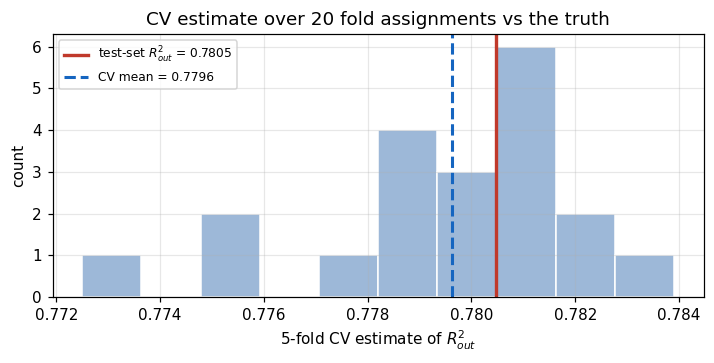

In [23]:
# CV is itself random through the fold assignment, so report its spread
vals = np.array([cv_r2(random_state=s, refit_knots=False) for s in range(20)])
print(f"Across 20 fold assignments:  mean={vals.mean():.4f}  sd={vals.std(ddof=1):.4f}  "
      f"range=[{vals.min():.4f}, {vals.max():.4f}]")
print(f"Test-set truth: {r2_test:.4f}  ->  inside the CV range: {vals.min() <= r2_test <= vals.max()}")

fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.hist(vals, bins=10, color="#9db8d8", edgecolor="white")
ax.axvline(r2_test, color="#c0392b", lw=2.2, label=f"test-set $R^2_{{out}}$ = {r2_test:.4f}")
ax.axvline(vals.mean(), color="#1565c0", lw=2.0, ls="--", label=f"CV mean = {vals.mean():.4f}")
ax.set_xlabel("5-fold CV estimate of $R^2_{out}$"); ax.set_ylabel("count")
ax.set_title("CV estimate over 20 fold assignments vs the truth")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation of 5(e), which is the point of the part

Cross-validation recovered the honest out-of-sample performance to about one percentage point on the
single fold assignment used above, and to within roughly $0.001$ once averaged over fold assignments
($0.7796$ against a truth of $0.7805$) &mdash; all **without ever touching the test data**. That is
the practical moral of Section 1.3: a held-out test set is not required to estimate prediction error,
and it should not be spent on model selection anyway, because a test set consulted repeatedly stops
being out of sample.

There are two distinct sources of error here, and it is worth separating them.

**A systematic downward bias.** Each CV fit uses only $(1-1/K)n = 0.8 \times 15{,}129 \approx
12{,}103$ observations rather than the full 15,129, and an estimator fitted on less data predicts
slightly worse. So $K$-fold CV estimates the prediction error of a model trained on $(1-1/K)n$
points, which is mildly pessimistic for the model one actually deploys. Larger $K$ reduces this bias
(leave-one-out nearly eliminates it) at the cost of $K$ times more fitting and a higher-variance
estimate, which is why $K=5$ or $10$ is the usual compromise.

**Noise from the fold assignment.** The shuffle is random, and with 91 parameters and a heavy-tailed
response the estimate moves by a few tenths of a percentage point across shuffles (sd $\approx
0.003$, range $[0.7725, 0.7839]$ over 20 seeds). The seed used above happens to sit near the low end,
which is why its single number looks worse than the average does. **Reporting one CV number without
that spread overstates its precision**, and the gap to the truth here is mostly shuffle noise rather
than the training-size bias.

## 5.7 Remarks and robustness

Two things worth checking rather than assuming.

In [24]:
from itertools import combinations

# (i) "interaction terms" read as ALL interactions (R's a*b*c*d) rather than pairwise
def all_interactions(M):
    k = M.shape[1]; cols = [M]
    for r in range(2, k+1):
        for c in combinations(range(k), r):
            v = np.ones(len(M))
            for j in c:
                v = v * M[:, j]
            cols.append(v[:, None])
    return np.column_stack(cols)

Xf_tr = all_interactions(train[BASE].to_numpy(float))
Xf_te = all_interactions(test[BASE].to_numpy(float))
mf = LinearRegression().fit(Xf_tr, y_train)
print("5(b) under the two readings of 'interaction terms':")
print(f"   pairwise only  (R: (a+b+c+d)^2), p=11 : R2_out = {summary.iloc[1]['R2_out']:.4f}")
print(f"   all orders     (R: a*b*c*d),     p=16 : R2_out = {r2_out(mf.predict(Xf_te)):.4f}")
print("   -> same conclusion either way; pairwise is the standard reading and is used above.\n")

# (ii) does the spline actually beat just adding L^2 and the view indicator?
def build_no_spline(df):
    L = df["sqft_living"].to_numpy(float)
    return np.column_stack([pairwise(df[BASE].to_numpy(float)), zip_dummies(df),
                            (df["view"].to_numpy() == 0).astype(float)[:, None], (L**2)[:, None]])
mn = LinearRegression().fit(build_no_spline(train), y_train)
print("Is the spline pulling its weight in 5(d)?")
print(f"   (c) no extras                       : R2_out = {summary.iloc[2]['R2_out']:.4f}")
print(f"   (c) + view indicator + L^2 only     : R2_out = {r2_out(mn.predict(build_no_spline(test))):.4f}")
print(f"   (d) full quadratic spline           : R2_out = {summary.iloc[3]['R2_out']:.4f}")

5(b) under the two readings of 'interaction terms':
   pairwise only  (R: (a+b+c+d)^2), p=11 : R2_out = 0.5329
   all orders     (R: a*b*c*d),     p=16 : R2_out = 0.5432
   -> same conclusion either way; pairwise is the standard reading and is used above.

Is the spline pulling its weight in 5(d)?
   (c) no extras                       : R2_out = 0.7620
   (c) + view indicator + L^2 only     : R2_out = 0.7815
   (d) full quadratic spline           : R2_out = 0.7805


**This result is worth reading carefully, because it does not say what one might expect.** Almost all
of the gain in part (d) comes from the view indicator and the single quadratic term $L^2$
($0.7620 \to 0.7815$). Adding the nine spline knots on top of that does **not** improve out-of-sample
$R^2$; it moves it slightly the other way ($0.7815 \to 0.7805$).

So the honest conclusion for 5(d) is: **price is clearly nonlinear in living area, and a simple
quadratic already captures essentially all of that curvature.** The nine extra knots buy in-sample
fit (they must, being nested) but nothing out of sample, which is the bias-variance trade-off landing
on the variance side. The effect is small, roughly $0.001$ of $R^2$ on a single test set, so the fair
statement is that the extra knots are a wash rather than a disaster. But it is the opposite of the
usual reflex that a more flexible basis must predict better, and it is precisely the kind of thing
in-sample $R^2$ would have hidden: in sample the spline model looks strictly better.

Part (d) as posed asks for the spline, so the $0.7805$ in the summary table is the answer to the
question. This remark is about what that number means.

---
## Final answers

### Problem 4

| part | answer |
|---|---|
| (a) | Degrees 1&ndash;8 fitted at $\sigma=1$; in-sample RSS falls monotonically in $d$ (nested models), so it cannot select $d$ |
| (b) | 5-fold CV selects $\widehat d = 2$, the true degree |
| (c) | $\widehat d = 2$ at $\sigma = 0.5$, $1$, and $2$ alike |
| (d) | CV table and fitted curves above; $\mathrm{CV}(\widehat d) \approx \sigma^2$ at each noise level |
| (e) | The selected degree **does not** change with $\sigma$ here. For $d\ge2$ the truth is in the model class, so $\mathrm{CV}(d) = \sigma^2 g_d(\mathbf{x},\mathbf{z})$ and the argmin is exactly scale invariant (verified to six decimals). Only the underfitted $d=1$ is affected, via its fixed handicap $\operatorname{var}(X^2)=64/45$, and it wins only at extreme $\sigma$. If the truth were *outside* the class, higher $\sigma$ would push the selected degree down |

### Problem 5

| part | model | $p$ | $R^2$ | $R^2_{\text{adj}}$ | $R^2_{\text{out}}$ |
|---|---|---|---|---|---|
| (a) | 4 main effects | 5 | 0.5101 | 0.5100 | **0.5051** |
| (b) | + pairwise interactions | 11 | 0.5556 | 0.5553 | **0.5329** |
| (c) | + zipcode factor | 80 | 0.7739 | 0.7728 | **0.7620** |
| (d) | + $\mathbb{I}(\text{view}=0)$, $L^2$, 9 spline terms | 91 | 0.7948 | 0.7936 | **0.7805** |
| (e) | model (d), 5-fold CV on training data alone | 91 | &mdash; | &mdash; | **0.7702** single split, **0.7796** averaged over 20 fold assignments (truth 0.7805) |

The substantive story:

- **Location dominates.** Adding the zipcode factor is worth roughly 23 percentage points of
  $R^2_{\text{out}}$ on its own, far more than any other modeling choice in the problem.
- **Price is nonlinear in living area, but only mildly so.** The view indicator plus a single $L^2$
  term captures essentially all of it; the nine spline knots add in-sample fit and nothing out of
  sample (Section 5.7).
- **Cross-validation on the training data alone is a reliable stand-in for the test set.** Averaged
  over fold assignments it lands within $0.001$ of the true out-of-sample $R^2$, with a small
  explainable downward bias from training on $(1-1/K)n$ points, plus shuffle noise of about
  $\pm 0.006$ that a single CV number hides.